In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Topic 5 slide 31
x_data = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_data = np.array([1.0, 3.0, 2.0, 5.0, 4.0])

In [3]:
def lagrange_interpolation(x_data, y_data, x_val):
    n = len(x_data)
    result = 0.0
    for i in range(n):
        l_i = 1.0
        for j in range(n):
            if i != j:
                l_i *= (x_val - x_data[j]) / (x_data[i] - x_data[j])
        
        result += y_data[i] * l_i
    return result

In [4]:
def newton_divided_difference(x_data, y_data):
    n = len(y_data)
    coef = np.zeros([n, n])
    coef[:, 0] = y_data 
    
    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x_data[i+j] - x_data[i])
    return coef[0, :]

def newton_interpolation(x_data, y_data, x_val):
    coef = newton_divided_difference(x_data, y_data)
    n = len(x_data)
    
    result = coef[0]
    for i in range(1, n):
        term = coef[i]
        for j in range(i):
            term *= (x_val - x_data[j])
        result += term
    return result

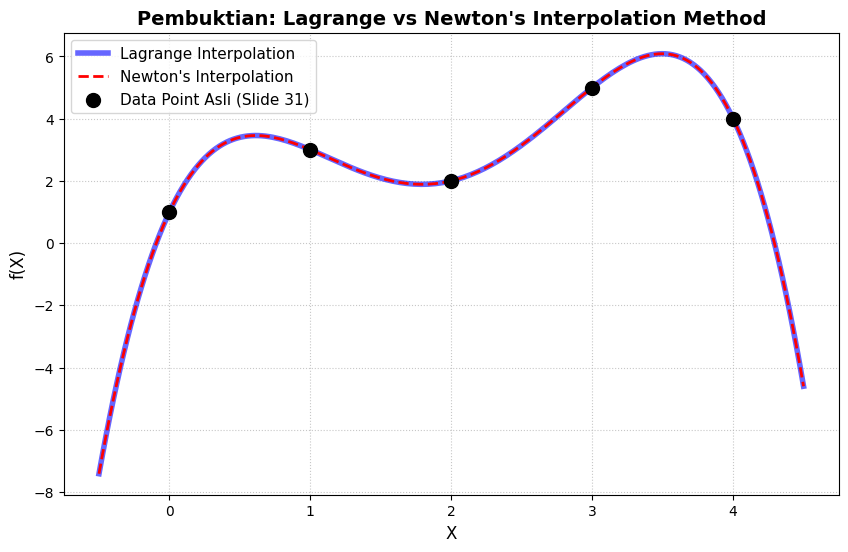

=== PENGUJIAN SAMPEL TITIK ===
Nilai interpolasi pada X = 1.5:
Metode Lagrange : 2.0859
Metode Newton   : 2.0859


In [5]:
if __name__ == "__main__":
    x_smooth = np.linspace(min(x_data) - 0.5, max(x_data) + 0.5, 200)
    
    y_lagrange = [lagrange_interpolation(x_data, y_data, x) for x in x_smooth]
    y_newton = [newton_interpolation(x_data, y_data, x) for x in x_smooth]
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(x_smooth, y_lagrange, color='blue', linewidth=4, alpha=0.6, label='Lagrange Interpolation')
    plt.plot(x_smooth, y_newton, color='red', linestyle='--', linewidth=2, label="Newton's Interpolation")
    
    #Plot Titik Data Asli
    plt.scatter(x_data, y_data, color='black', s=100, zorder=5, label='Data Point Asli (Slide 31)')
    
    plt.title("Pembuktian: Lagrange vs Newton's Interpolation Method", fontsize=14, fontweight='bold')
    plt.xlabel("X", fontsize=12)
    plt.ylabel("f(X)", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.show()
    
    print("=== PENGUJIAN SAMPEL TITIK ===")
    test_val = 1.5
    print(f"Nilai interpolasi pada X = {test_val}:")
    print(f"Metode Lagrange : {lagrange_interpolation(x_data, y_data, test_val):.4f}")
    print(f"Metode Newton   : {newton_interpolation(x_data, y_data, test_val):.4f}")